In [1]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import copy

# Load dataset

In [2]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "pororo")
qa_json_path = os.path.join(base_dir, "qa.json")
description_csv_path = os.path.join(base_dir, "descriptions.csv")

def load_dataset(qa_json_path, description_csv_path):
    try:
        with open(qa_json_path, "r") as f:
            qa_data = json.load(f)["PororoQA"]
        descriptions = pd.read_csv(description_csv_path)
        return qa_data, descriptions
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], pd.DataFrame()

# Initialize a single cached dataset dictionary, similar to simpsons_ablation_study.ipynb
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    """Get a fresh, isolated copy of the dataset to prevent cross-configuration contamination"""
    global cached_dataset
    
    # Load from disk if not cached or forced reload
    if cached_dataset is None or reload:
        print("Loading dataset from disk...")
        qa_data, descriptions = load_dataset(qa_json_path, description_csv_path)
        cached_dataset = {
            'qa_data': qa_data,
            'descriptions': descriptions,
            'gif_paths': {},
            'question_data': {}
        }
    else:
        print("Using cached dataset but creating a deep copy to prevent contamination...")
    
    # Always return deep copies to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['qa_data']), \
           cached_dataset['descriptions'].copy(deep=True)

# TODO increase questions
def get_random_questions(qa_data, max_questions=40, base_pattern="Pororo_ENGLISH1", seed=42):
    random.seed(seed)

    # Filter all eligible questions
    filtered_questions = [q for q in qa_data if base_pattern in q["video_name"]]

    # Group by unique (video_name, supporting_num) pairs to avoid duplicates
    unique_pairs = {}
    for q in filtered_questions:
        key = (q["video_name"], q["supporting_num"])
        if key not in unique_pairs:
            unique_pairs[key] = []
        unique_pairs[key].append(q)

    # Sample from unique pairs
    unique_keys = list(unique_pairs.keys())
    selected_keys = random.sample(unique_keys, min(max_questions, len(unique_keys)))

    # Get one question from each selected pair
    sampled_questions = []
    episode_counts = {}

    for key in selected_keys:
        question = random.choice(unique_pairs[key])
        sampled_questions.append(question)
        episode = question["video_name"]
        episode_counts[episode] = episode_counts.get(episode, 0) + 1

    # Group by season for display
    season_episodes = {
        "Pororo_ENGLISH1_1": [],
        "Pororo_ENGLISH1_2": [],
        "Pororo_ENGLISH1_3": []
    }

    for ep in episode_counts.keys():
        season = "_".join(ep.split("_")[:3])
        if season in season_episodes:
            season_episodes[season].append(ep)

    # Do not print here; return the info for printing elsewhere
    return sampled_questions, episode_counts, season_episodes

def get_seeded_question(questions, gif_num, base_seed=42):
    """Get deterministic random question for a GIF"""
    if not questions:
        return None
    local_random = random.Random(base_seed + gif_num)
    sorted_questions = sorted(questions, key=lambda x: x["qid"])
    return local_random.choice(sorted_questions)

def encode_gif(gif_path):
    try:
        if not os.path.exists(gif_path):
            print(f"Error: GIF not found at {gif_path}")
            return None
        with open(gif_path, "rb") as gif_file:
            image_base64 = base64.b64encode(gif_file.read()).decode('utf-8')
            return image_base64
    except Exception as e:
        print(f"Error encoding GIF: {e}")
        return None

def prepare_dataset():
    """Prepare a fresh dataset with isolated question data and gif paths"""
    # Get fresh dataset copies
    qa_data, descriptions = get_fresh_dataset()

    # Get random sample of questions and episode info
    sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)

    # Group questions by supporting_num
    grouped_questions = {}
    for entry in sampled_questions:
        video_name = entry["video_name"]
        supporting_num = entry["supporting_num"]
        key = (video_name, supporting_num)
        if key not in grouped_questions:
            grouped_questions[key] = []
        grouped_questions[key].append(entry)

    # Get unique pairs to process
    gif_pairs = sorted(list(grouped_questions.keys()))

    # Prepare question data and gif paths
    question_data = {}
    gif_paths = {}
    
    for video_name, gif_num in gif_pairs:
        current_questions = grouped_questions[(video_name, gif_num)]
        if current_questions:
            entry = get_seeded_question(current_questions, int(gif_num))

            question = entry["question"]
            correct_idx = entry["correct_idx"]
            answers = [entry[f"answer{i}"] for i in range(5)]
            correct_answer = answers[correct_idx]
            qid = entry["qid"]

            question_data[(video_name, gif_num)] = {
                'entry': entry,
                'question': question,
                'correct_answer': correct_answer,
                'qid': qid
            }

            # gif path
            episode_parts = video_name.split("_")
            episode_folder = os.path.join(base_dir, "Scenes_Dialogues",
                                "_".join(episode_parts[:-1]),
                                video_name)
            gif_paths[(video_name, gif_num)] = os.path.join(episode_folder, f"{gif_num}.gif")
    
    return descriptions, gif_pairs, question_data, gif_paths

def print_dataset_summary(sampled_questions, episode_counts, season_episodes):
    """Print a summary of the selected questions from the dataset"""
    print(f"\nSelected {len(sampled_questions)} questions from {len(episode_counts)} episodes:")
    
    for season in sorted(season_episodes.keys()):
        season_eps = {ep: episode_counts[ep] for ep in season_episodes[season]}
        if season_eps:
            print(f"\n{season}:")
            for ep in sorted(season_eps.keys()):
                print(f"  {ep}: {season_eps[ep]} questions")

# Example of loading and displaying dataset information
qa_data, descriptions = get_fresh_dataset()
sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)
print_dataset_summary(sampled_questions, episode_counts, season_episodes)

# Initialize results list
results_ablation = []

# Ablation Study Configuration
# Initializing the agents
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False

Loading dataset from disk...

Selected 40 questions from 22 episodes:

Pororo_ENGLISH1_1:
  Pororo_ENGLISH1_1_ep1: 1 questions
  Pororo_ENGLISH1_1_ep10: 2 questions
  Pororo_ENGLISH1_1_ep11: 1 questions
  Pororo_ENGLISH1_1_ep12: 4 questions
  Pororo_ENGLISH1_1_ep13: 2 questions
  Pororo_ENGLISH1_1_ep2: 4 questions
  Pororo_ENGLISH1_1_ep5: 1 questions
  Pororo_ENGLISH1_1_ep6: 4 questions
  Pororo_ENGLISH1_1_ep9: 1 questions

Pororo_ENGLISH1_2:
  Pororo_ENGLISH1_2_ep10: 1 questions
  Pororo_ENGLISH1_2_ep2: 2 questions
  Pororo_ENGLISH1_2_ep5: 2 questions
  Pororo_ENGLISH1_2_ep8: 3 questions

Pororo_ENGLISH1_3:
  Pororo_ENGLISH1_3_ep1: 1 questions
  Pororo_ENGLISH1_3_ep11: 1 questions
  Pororo_ENGLISH1_3_ep12: 2 questions
  Pororo_ENGLISH1_3_ep13: 1 questions
  Pororo_ENGLISH1_3_ep2: 1 questions
  Pororo_ENGLISH1_3_ep3: 1 questions
  Pororo_ENGLISH1_3_ep4: 1 questions
  Pororo_ENGLISH1_3_ep5: 2 questions
  Pororo_ENGLISH1_3_ep7: 2 questions


# Agents Configuration

In [3]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Visual agent: handles image-related tasks, and outputs image description
def visual_agent(image_base64, question, description, subtitles, max_retries=3, retry_delay=2):
    # If visual agent is disabled, return a basic placeholder
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from Pororo."
        
    prompt = f"""
    You are a Pororo cartoon visual analysis expert. Focus on the question "{question}" to generate visual elements.
    Analyze the given image and generate a CONCISE and FACTUAL VISUAL DESCRIPTION.
    Your response must be based ONLY on what is VISUALLY present in the image.
    You are also provided with subtitles "{subtitles}" and a scene description text "{description}" to help disambiguate the visual content. Use the text information to avoid critic or misinterpretation, but do not repeat or paraphrase it.

    Task: Generate a short, grounded visual description based on the image and the context below.

    Strictly follow these guidelines:
    - Limit your description to **3-4 sentences maximum**
    - Use **simple, clear language** and avoid redundancy
    - Focus on the following aspects if visually present:
        1. Character: Visible character with notable visual traits
        2. Action: What is being done (body posture, gesture)
        3. Scene: Indoor/outdoor, main environment
        4. Key Object: Only if directly relevant
        5. Position: Where thing is (e.g., "on the left", "in the background")
        6. Color: Only mention color if directly relevant to the question

    Do NOT include:
    - Opinions, guesses, or emotions
    - Storyline interpretation or external context

    Be concise. Stay grounded in what is visible only.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0
                )
                visual_description = completion.choices[0].message.content.strip()
                return visual_description
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/gif",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                visual_description = completion.content[0].text.strip()
                return visual_description

        except Exception as e:
            print(f"Visual agent attempt {attempt+1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return "Error: Unable to analyze the image after multiple attempts."

# Language agent: handles text-related tasks, and outputs initial predicted answer
def language_agent(question, image_base64, visual_description, description, subtitles, max_retries=3, retry_delay=2):
    # If language agent is disabled but this function is still called, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from Pororo."

    prompt = f"""
    As a cartoon language expert, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE SENTENCE within 30 words.

    Evidence:
    Scene Description: "{description}"
    Subtitles: "{subtitles}"
    Visual Description: "{visual_description}"

    Guidelines:
    1. No explanations allowed.
    2. Response must be in English only. DO NOT include text in any other language.
    3. Avoid phrases like "based on ...", "according to..." or "the description prided..."   
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,  
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url":
                                        {"url": f"data:image/gif;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=50,
                    temperature=0.0,
                )
                initial_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/gif", "data": image_base64}},
                        ]
                    }],
                    max_tokens=50,
                    temperature=0.0,
                )
                initial_answer = completion.content[0].text.strip().lower()

            # Extract the first complete sentence (including ending punctuation)
            match = re.search(r'^.*?[.!?](?=\s|$)', initial_answer)
            if match:
                first_sentence = match.group(0).strip()
            else:
                first_sentence = initial_answer

            # If there's no ending punctuation, use the entire answer
            if not first_sentence:
                first_sentence = initial_answer

            # Check if quotes are unbalanced and fix them
            quotes_count = first_sentence.count('"')
            if quotes_count % 2 == 1:  # Odd number of quotes means they're unbalanced
                # Find the first quote position in the remaining text
                remaining_text = initial_answer[len(first_sentence):].strip()
                next_quote_pos = remaining_text.find('"')
                if next_quote_pos != -1:
                    # Include the text up to and including the closing quote
                    first_sentence += remaining_text[:next_quote_pos+1]

            return first_sentence

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

# critic detection agent: implement as a Critic agent that evaluates and potentially corrects answers
def classify_question_type(question):
    question_lower = question.lower()
    
    # Dialogue/Speech questions (very common in Pororo)
    if any(pattern in question_lower for pattern in ['say', 'tell', 'ask', 'said', 'told', 'asks', 'answer', 'propose']):
        return 'dialogue'
    
    # Action questions (refined with common Pororo actions)
    elif any(pattern in question_lower for pattern in ['do', 'did', 'doing', 'action', 'activity', 'run', 'play', 'clean', 'move', 'find']):
        return 'action'
        
    # Character interaction questions
    elif any(pattern in question_lower for pattern in ['interrupt', 'help', 'invite', 'together', 'group', 'friend']):
        return 'interaction'
        
    # Object-related questions
    elif any(pattern in question_lower for pattern in ['what is', 'what was', 'toy', 'object', 'explode', 'broke', 'camera', 'box', 'flower']):
        return 'object'
    
    # Color questions
    elif any(pattern in question_lower for pattern in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'
    
    # Counting/numeric questions
    elif any(pattern in question_lower for pattern in ['how many', 'count', 'number']):
        return 'count'
    
    # Existence and state questions
    elif any(pattern in question_lower for pattern in ['is there', 'are there', 'does', 'did', 'do you see', 'can you', 'was there']):
        return 'existence'
    
    # Location questions
    elif any(pattern in question_lower for pattern in ['where', 'location', 'place', 'position', 'on the', 'in the', 'behind', 'under']):
        return 'location'
    
    # Temporal questions
    elif any(pattern in question_lower for pattern in ['when', 'time', 'after', 'before', 'next', 'tomorrow', 'yesterday', 'then']):
        return 'temporal'
    
    # Yes/No questions
    elif question_lower.startswith(('is ', 'are ', 'did ', 'do ', 'does ', 'has ', 'have ', 'can ', 'will ', 'would ')):
        return 'yes_no'
    
    # Default
    return 'other'

def critic_agent(question, image_base64, initial_answer, visual_description, description, subtitles, max_retries=3, retry_delay=2, verbose=False):

    if not ENABLE_CRITIC_AGENT or initial_answer is None:
        return initial_answer, False, {}

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from Pororo."
    force_poor_visual_description_quality = not ENABLE_VISUAL_AGENT
    question_type = classify_question_type(question)

   
    prompt = f"""
    You are a cartoon critic expert. Focus on the question “{question}”, evaluate the initial answer "{initial_answer}" and provide a confident final answer based on the available evidence.

    Step 1: Assess the Visual Description quality "{visual_description}"
    - If the visual description is clear, detailed, and relevant for answering the question, set VISUAL_DESCRIPTION_QUALITY: GOOD
    - If the visual description is ambiguous, misleading, or lacks relevance, set VISUAL_Description_QUALITY: POOR

    Step 2: Reasoning Strategy:
    - If VISUAL_DESCRIPTION_QUALITY is GOOD, consider all available evidence including the visual description "{visual_description}", image, scene description "{description}", and subtitles "{subtitles}".
    - If VISUAL_DESCRIPTION_QUALITY is POOR, ignore the visual description "{visual_description}", but still use the image alongside the scene description "{description}" and subtitles "{subtitles}".

    Step 3: Reference Materials Evaluation
    Carefully review the Scene description and Subtitles provided in Step 2 as trusted sources. Use the following guidelines based on the specific question type "{question_type}":
    - 'color': Verify colors clearly mentioned in descriptions or subtitles.
    - 'count': Count entities precisely using descriptions or subtitles.
    - 'action': Identify actions clearly stated or described in descriptions or subtitles.
    - 'existence': Confirm explicitly mentioned entities or actions in context.
    - 'location': Confirm positional descriptions (e.g., "behind," "next to") in the scene description.
    - 'dialogue': Rely explicitly on dialogues mentioned in subtitles.
    - 'interaction': Evaluate described interactions between characters in descriptions/subtitles.
    - 'object': Match objects clearly mentioned in descriptions or subtitles.
    - 'temporal': Confirm any explicit timeline or sequence mentioned.
    - 'yes_no': Clearly confirm or deny based on explicit evidence provided.
    - 'other': Consider all evidence provided collectively for general accuracy.

    Step 4: Confidence Level and Final Answer
    Evaluate your confidence in the initial answer "{initial_answer}":
    - MODEL_CONFIDENCE: 1.0 - Very high certainty that initial answer is correct based on clear evidence.
    - MODEL_CONFIDENCE: 0.75 - Good confidence that initial answer is correct with supporting evidence.
    - MODEL_CONFIDENCE: 0.5 - Moderate confidence in the initial answer.
    - MODEL_CONFIDENCE: 0.25 - Low confidence in the initial answer due to unclear or contradictory evidence.
    - MODEL_CONFIDENCE: 0.0 - Very uncertain about initial answer, likely incorrect.
    
    If MODEL_CONFIDENCE is less than 0.75 or you find inconsistencies in the evidence, provide a revised answer.
    Make sure your final answer directly answers the question within one sentence and 30 WORDS MAXIMUM.
    
    Your final response must strictly follow this format:
    VISUAL_DESCRIPTION_QUALITY: [GOOD / POOR]
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]
    EXPLANATION: [brief justification]
    VISUAL_EVIDENCE: [if visual was used, explain which part helped]
    FINAL_ANSWER: [Your final single-sentence answer]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                            ]
                        }
                    ],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/gif", "data": image_base64}},
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip().lower()

            # Extract response fields using regex
            visual_description_quality_match = re.search(r'VISUAL_DESCRIPTION_QUALITY:\s*(GOOD|POOR)', response, re.IGNORECASE)
            model_confidence_match = re.search(r'MODEL_CONFIDENCE:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\nVISUAL_EVIDENCE|FINAL_ANSWER|$)', response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\nFINAL_ANSWER|$)', response, re.IGNORECASE | re.DOTALL)
            final_answer_match = re.search(r'FINAL_ANSWER:\s*(.+)', response, re.IGNORECASE)
            
            # Parse the matches to get values
            visual_description_quality = visual_description_quality_match.group(1).strip().upper() if visual_description_quality_match else "POOR"
            model_confidence = float(model_confidence_match.group(1)) if model_confidence_match else 0.5
            explanation = explanation_match.group(1).strip() if explanation_match else "No explanation provided"
            visual_evidence = visual_evidence_match.group(1).strip() if visual_evidence_match else ""
            final_answer_candidate = final_answer_match.group(1).strip() if final_answer_match else initial_answer
            
            # Override visual quality if visual agent is disabled
            if force_poor_visual_description_quality:
                visual_description_quality = "POOR"
            
            if visual_description_quality == "POOR" and verbose:
                print("Visual description deemed unreliable.")

            # Extract first sentence from the final answer using regex
            match = re.search(r'^.*?[.!?](?=\s|$)', final_answer_candidate)
            if match:
                final_answer_candidate = match.group(0).strip()
            
            if not final_answer_candidate:
                final_answer_candidate = final_answer_match.group(1).strip() if final_answer_match else initial_answer
            
            # Handle balanced quote marks
            quotes_count = final_answer_candidate.count('"')
            if quotes_count % 2 == 1:  
                remaining_text = final_answer_match.group(1)[len(final_answer_candidate):] if final_answer_match else ""
                next_quote_pos = remaining_text.find('"')
                if next_quote_pos != -1:
                    final_answer_candidate += remaining_text[:next_quote_pos+1]

            # Normalize for comparison - preserve internal punctuation
            initial_answer_normalized = re.sub(r'[.!?,;:]+$', '', initial_answer).lower()
            final_answer_candidate_normalized = re.sub(r'[.!?,;:]+$', '', final_answer_candidate).lower()
            different = initial_answer_normalized != final_answer_candidate_normalized

            # Check for invalid answers - don't accept unknown, none, etc.
            invalid_answers = ['n/a', 'unknown', 'none', 'not', 'na', 'nothing', 'invisible', 'unseen', 'unclear']
            is_invalid = final_answer_candidate_normalized in invalid_answers or 'not visible' in final_answer_candidate_normalized
            
            if is_invalid:
                # Force keep the initial answer instead of using an invalid one
                final_answer = initial_answer
                changed = False
                if verbose:
                    print(f"Final answer '{final_answer_candidate}' is invalid. Keeping initial answer '{initial_answer}'.")
            # Improved decision logic that weighs visual and language information consistently
            elif visual_description_quality == "GOOD" and ENABLE_VISUAL_AGENT:
                # With good visual description, be selective about changes
                if model_confidence <= 0.75 and different:
                    final_answer = final_answer_candidate
                    changed = True
                    if verbose:
                        print("Good visual quality but low/medium confidence. Changing initial answer.")
                else:
                    # Trust initial answer when confidence is high
                    final_answer = initial_answer
                    changed = False
                    if verbose:
                        print("Good visual quality with high confidence. Keeping initial answer.")
            else:
                # Without good visual description, be more critical
                if model_confidence <= 0.25:
                    final_answer = final_answer_candidate
                    changed = different
                    if verbose:
                        print("Poor visual quality and low confidence. Changing initial answer.")
                elif model_confidence >= 0.75:
                    final_answer = initial_answer
                    changed = False
                    if verbose:
                        print("Poor visual quality but high confidence. Keeping initial answer.")
                else:
                    # With medium confidence, prefer the final answer candidate if different
                    final_answer = final_answer_candidate if different else initial_answer
                    changed = different
                    if verbose:
                        print("Poor visual quality with moderate confidence. " + 
                              ("Changing initial answer." if different else "Answers are identical, no change needed."))

            # Collect analysis data
            analysis_data = {
                'model_confidence': model_confidence,
                'visual_description_quality': visual_description_quality,
                'explanation': explanation,
                'visual_evidence': visual_evidence,
                'changed': changed
            }

            if verbose:
                print(f"--- Critic Agent Analysis ---")
                print(f"- VISUAL_DESCRIPTION_QUALITY: {visual_description_quality}")
                print(f"- MODEL_CONFIDENCE: {model_confidence}")
                print(f"- EXPLANATION: {explanation}")
                print(f"- VISUAL_EVIDENCE: {visual_evidence}")
                print(f"- INITIAL_ANSWER: {initial_answer}")
                print(f"- FINAL_ANSWER: {final_answer}")
                print(f"- CHANGED: {changed}")

            return final_answer, changed, analysis_data

        except Exception as e:
            if verbose:
                print(f"Critic agent error (attempt {attempt + 1}): {str(e)}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)

    if verbose:
        print("Critic agent failed after multiple attempts. Returning initial answer.")
    return initial_answer, False, {}

Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [4]:
def compute_accuracy(question, correct_answer, predicted_answer, max_retries=2, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == predicted_answer.lower().strip():
        return 1.0, [1.0] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Correct Answer: {correct_answer}
        Predicted Answer: {predicted_answer}

        Evaluation Rules:
        1. Focus PRIMARILY on semantic equivalence.
        2. Additional details should NEVER reduce the score if core information is correct.
        3. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering

        Scoring Examples:
        - Example of Score 1.0 (Perfect match or semantic equivalence):
        Question: "how did pororo feel after seeing that the flower has wilted"
        Correct: "he was very upset"
        Predicted: "pororo felt sad after seeing that the flower had wilted"
        Score: 1.0 (Synonyms with same core meaning)

        - Example of Score 1.0 (Additional details):
        Question: "what does crong do when pororo says 'come here'"
        Correct: "crong runs away from pororo"
        Predicted: "when pororo says 'come here,' crong tries to run away again"
        Score: 1.0 (Contains core information with additional details)

        - Example of Score 0.75 (Mostly correct but missing or slightly inaccurate information):
        Question: "what did loopy propose to the group after telling them about the flower"
        Correct: "loopy proposed that they should ask her anything"
        Predicted: "loopy proposed to the group that they ask the magic flower questions to predict the future"
        Score: 0.75 (Core action correct but adds slight inaccuracy about asking the flower directly)

        - Example of Score 0.5 (Partially correct):
        Question: "what does pororo almost forget to leave with poby"
        Correct: "the broken camera piece"
        Predicted: "pororo almost forgets to leave with poby's precious camera"
        Score: 0.5 (Mentions camera but misses the specific detail that it's broken)

        - Example of Score 0.25 (Slightly correct):
        Question: "what does eddy ask pororo"
        Correct: "he asks pororo what are you doing"
        Predicted: "eddy asks crong why pororo is acting so urgently"
        Score: 0.25 (Wrong recipient but related to pororo's actions)

        - Example of Score 0.0 (Completely incorrect):
        Question: "what was crong playing with as pororo entered the house"
        Correct: "crong was playing with a snowboard"
        Predicted: "crong was not shown playing with anything"
        Score: 0.0 (Directly contradicts the correct answer)
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0,
                    )
                    response = completion.content[0].text.strip()

                # Extract numeric score using regex
                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                # If all retries for this evaluation fail, continue to next evaluation

    # If all evaluations failed, return 0.0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get most common score
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

# Run experiments

In [5]:
# Define the configurations to test
configurations = [
    # Only Language agent
    {
        'visual': False,
        'language': True,
        'critic': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'critic': False,
        'name': 'visual_language'
    },
    #  Language + Critic agents
    {
        'visual': False,
        'language': True,
        'critic': True,
        'name': 'language_critic'
    },
    # Visual + Language + Critic agents
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

def run_experiment(enable_visual, enable_language, enable_critic, max_questions=40):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT

    # Store original configuration
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT
    }

    try:
        # Set configuration for this experiment
        ENABLE_VISUAL_AGENT = enable_visual
        ENABLE_LANGUAGE_AGENT = enable_language
        ENABLE_CRITIC_AGENT = enable_critic

        # Create configuration name
        config_parts = []
        if enable_visual:
            config_parts.append("visual")
        if enable_language:
            config_parts.append("language")
        if enable_critic:
            config_parts.append("critic")
        
        config_suffix = "_".join(config_parts)

        # Initialize results for this experiment
        results = []
        analysis_results = []  # For storing critic agent analysis data
        correct_count = 0
        accuracies = []
        total_processed = 0

        # Get a fresh dataset for this run - IMPORTANT to prevent data contamination
        descriptions, gif_pairs, question_data, gif_paths = prepare_dataset()

        # Define base column order - we'll adjust this based on enabled agents
        base_columns = [
            'row_num',
            'qid',
            'video_name', 
            'gif_num',
            'question',
            'correct_answer'
        ]
        
        # Conditionally add columns based on enabled agents
        column_order = base_columns.copy()
        
        if enable_visual:
            column_order.append('visual_description')
            
        if enable_language and enable_critic:
            column_order.extend(['initial_answer', 'predicted_answer'])
        else:
            column_order.append('predicted_answer')
        
        column_order.extend(['evaluator_scores', 'accuracy'])

        # Select question set to process
        pairs_to_process = gif_pairs[:max_questions]

        # Process each video and GIF pair
        for idx, (video_name, gif_num) in enumerate(tqdm(pairs_to_process, desc="Processing"), 1):
            # Skip if no question data available
            if (video_name, gif_num) not in question_data:
                print(f"\nNo question data found for {video_name} GIF {gif_num}")
                continue
                
            # Get question information
            q_info = question_data[(video_name, gif_num)]
            question = q_info['question']
            correct_answer = q_info['correct_answer']
            qid = q_info['qid']
            
            # Get gif path and resources
            gif_path = gif_paths[(video_name, gif_num)]
            gif_directory = os.path.dirname(gif_path)
            
            # Load subtitles
            try:
                with open(os.path.join(gif_directory, "subtitles.txt"), "r") as f:
                    subtitles = f.read()
            except FileNotFoundError:
                subtitles = ""

            # Get description
            description_rows = descriptions.loc[
                (descriptions.iloc[:, 0] == video_name) &
                (descriptions.iloc[:, 1] == int(gif_num))
            ]
            if description_rows.empty:
                print(f"Description for {video_name} GIF {gif_num} not found")
                continue

            descriptions_list = description_rows.iloc[:, 2].tolist()
            description = " ".join(descriptions_list)
            
            # Encode GIF to base64
            image_base64 = encode_gif(gif_path)
            if not image_base64:
                print(f"Error: Failed to encode GIF {gif_num}")
                continue
            
            # Get visual description (will be placeholder if visual agent disabled)
            visual_description = visual_agent(image_base64, question=question, description=description, subtitles=subtitles)
            if visual_description is None:
                print(f"Error: Visual agent failed to process GIF {gif_num}")
                continue

            # Handle prediction based on enabled agents
            if enable_language:
                # Get language agent prediction
                initial_answer = language_agent(question, image_base64, visual_description, description, subtitles)
                if initial_answer is None:
                    print(f"Error for question {qid} - Failed to generate answer")
                    continue
                
                # Get critic agent improvement if enabled
                if enable_critic:
                    final_answer, changed, analysis_data = critic_agent(
                        question=question,
                        image_base64=image_base64,
                        initial_answer=initial_answer,
                        visual_description=visual_description,
                        description=description,
                        subtitles=subtitles,
                        verbose=True
                    )
                    analysis_data['final_answer'] = final_answer
                    critic_analysis = {
                        'row_num': len(analysis_results) + 1,
                        'video_name': video_name,
                        'gif_num': gif_num,
                        'qid': qid,
                        'question': question,
                        'correct_answer': correct_answer,
                        'initial_answer': initial_answer,
                        'predicted_answer': final_answer,
                        'model_confidence': analysis_data.get('model_confidence', ''),
                        'visual_description_quality': analysis_data.get('visual_description_quality', ''),
                        'explanation': analysis_data.get('explanation', ''),
                        'visual_evidence': analysis_data.get('visual_evidence', ''),
                        'changed': analysis_data.get('changed', '')
                    }
                    analysis_results.append(critic_analysis)
                    predicted_answer = final_answer if final_answer else initial_answer
                else:
                    predicted_answer = initial_answer
            else:
                # Visual-only mode: extract answer from visual description
                sentences = re.split(r'[.!?]', visual_description)
                short_desc = ". ".join(s.strip() for s in sentences[:2] if s.strip())
                predicted_answer = short_desc[:100] if short_desc else "unknown"
                initial_answer = predicted_answer  # Set initial_answer the same as predicted_answer in this case
            
            # Calculate accuracy
            is_correct, scores = compute_accuracy(question, correct_answer, predicted_answer)
            correct_count += is_correct
            accuracies.append(is_correct)
            total_processed += 1
            
            # Store result - create a base result with only the required columns
            result = {
                'gif_num': gif_num,
                'video_name': video_name,
                'qid': qid,
                'question': question,
                'correct_answer': correct_answer,
                'predicted_answer': predicted_answer,
                'evaluator_scores': ','.join([str(score) for score in scores]) if scores else '',
                'accuracy': is_correct
            }
            
            # Conditionally add columns based on which agents are enabled
            if enable_visual:
                result['visual_description'] = visual_description
                
            if enable_language and enable_critic:
                result['initial_answer'] = initial_answer
                
            results.append(result)

            print(f"Video name: {video_name}")
            print(f"GIF number: {gif_num}")
            print(f"QID: {qid}")
            print(f"Question: {question}")
            print(f"Correct Answer: {correct_answer}")
            
            # Only display visual description if visual agent is enabled
            if enable_visual:
                print(f"Visual Description: {visual_description}")
            
            # Only display initial answer if language agent is enabled and there's a distinction between initial and final answers
            if enable_language and enable_critic:
                print(f"Initial Answer: {initial_answer}")
                print(f"Predicted Answer: {predicted_answer}")
            else:
                print(f"Predicted Answer: {predicted_answer}")
                
            print(f"Evaluator Scores: {scores}")
            print(f"Accuracy: {is_correct:.4f}\n")

        # Calculate overall accuracy
        accuracy = sum(accuracies) / len(accuracies) if accuracies else 0
        print(f"\nOverall Accuracy: {accuracy:.4f}")
        
        # Save results with the correct column order
        # Clean up ablation results to remove any existing average rows
        results_to_save = [r for r in results if r.get('gif_num') != 'Average']
        
        # Add row numbers to each result
        for i, result in enumerate(results_to_save, 1):
            result['row_num'] = i

        safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
        results_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(results_dir, exist_ok=True)
        os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
                
        # Save to ablation subdirectory with configuration in filename
        output_path = os.path.join(results_dir, "ablation", f'pororo_ablation_{config_suffix}_{safe_model_name}.csv')
        
        # Convert to DataFrame and save with error handling
        try:
            results_df = pd.DataFrame(results_to_save)
            
            # Use the correctly filtered column_order
            filtered_columns = [col for col in column_order if col in results_df.columns]
            results_df = results_df[filtered_columns]
            
            results_df.to_csv(output_path, index=False)
            print(f"Results successfully saved to: {output_path}")
        except Exception as e:
            print(f"Error saving results to CSV: {e}")
        

        # Save analysis results if critic agent was enabled
        if enable_critic and analysis_results:
            analysis_dir = os.path.join(results_dir, "analysis")
            os.makedirs(analysis_dir, exist_ok=True)
            analysis_path = os.path.join(
                analysis_dir, f'pororo_analysis_{config_suffix}_{safe_model_name}.csv'
            )

            # Create analysis DataFrame
            analysis_df = pd.DataFrame(analysis_results)
            
            # Add average row to analysis results - similar to the main results
            if analysis_results:
                # Calculate average confidence
                avg_confidence = sum(float(r['model_confidence']) for r in analysis_results if r.get('model_confidence', '') != '') / len(analysis_results) if analysis_results else 0
                
                # Count changes
                changed_count = sum(1 for r in analysis_results if r.get('changed', False))

                # Calculate accuracy average from results_to_save
                avg_accuracy = accuracy  # Use the same average accuracy as the main results
                
                # Create average row
                average_analysis = {
                    'row_num': len(analysis_results) + 1,
                    'video_name': 'Average',
                    'gif_num': 'Average',
                    'qid': 'Average',
                    'question': '',
                    'correct_answer': '',
                    'initial_answer': '',
                    'predicted_answer': '',
                    'model_confidence': avg_confidence,
                    'visual_description_quality': '',
                    'explanation': '',
                    'visual_evidence': '',
                    'changed': f"{changed_count}/{len(analysis_results)}"
                }
                
                # Add to DataFrame
                analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)

            # Define analysis column order
            analysis_columns = [
                'row_num', 'video_name', 'gif_num', 'qid', 'question',
                'correct_answer', 'initial_answer', 'predicted_answer', 'model_confidence',
                'visual_description_quality', 'explanation', 'visual_evidence', 'changed'
            ]
            
            # Filter to only include columns that exist
            existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
            analysis_df = analysis_df[existing_analysis_columns]
            
            # Check if file exists and remove it
            if os.path.exists(analysis_path):
                os.remove(analysis_path)
                print(f"Existing analysis file removed: {analysis_path}")
            
            # Save analysis data
            analysis_df.to_csv(analysis_path, index=False)
            print(f"Critic analysis data saved to: {analysis_path}")
        
        return results, accuracy

    except Exception as e:
        print(f"Error in {config_suffix} configuration: {e}")
        return [], 0.0
    finally:
        # Always restore the original configuration even if there's an error
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']

# Run all ablation experiments sequentially and store results
all_accuracies = {}
all_results = {}

print("Prepare to run all ablation study configurations...")
for config in configurations:
    print(f"{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    results, accuracy = run_experiment(
        enable_visual=config['visual'],
        enable_language=config['language'],
        enable_critic=config['critic'],
    )
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue

    # Add the missing print statement for configuration completion
    print(f"Configuration {config['name']} finished with accuracy: {accuracy:.4f}")

    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results

Prepare to run all ablation study configurations...
Running configuration: language
Using cached dataset but creating a deep copy to prevent contamination...


Processing:   2%|▎         | 1/40 [00:06<04:11,  6.44s/it]

Video name: Pororo_ENGLISH1_1_ep1
GIF number: 14
QID: 383
Question: whtat does eddy ask pororo
Correct Answer: he asks pororo what are you doing
Predicted Answer: eddy asks crong why pororo is acting urgently.
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.2500



Processing:   5%|▌         | 2/40 [00:10<03:11,  5.03s/it]

Video name: Pororo_ENGLISH1_1_ep10
GIF number: 12
QID: 1100
Question: were eddy's friends interested seeing his new toy?
Correct Answer: yes, they ran happily towards the new toy.
Predicted Answer: yes, eddy's friends were interested in seeing his new toy, as they expressed excitement and planned to ride it together.
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000



...

Video name: Pororo_ENGLISH1_3_ep5
GIF number: 25
QID: 2333
Question: does the friends find pororo behind the snow man?
Correct Answer: the friends find pororo behind the snow man.
Visual Description: In the snowy outdoor scene, four characters are visible: Loopy, a pink otter; Poby, a white bear; Crong, a green dinosaur; and Eddy, an orange fox. They are standing together, facing towards the viewer, with cheerful expressions. The background features snow-covered trees and a clear blue sky. There is no visible snowman or indication of Pororo's presence in the image.
Initial Answer: no, the friends do not find pororo behind the snowman as there is no snowman or indication of pororo's presence in the scene.
Predicted Answer: no, the friends do not find pororo behind the snowman as there is no snowman or indication of pororo's presence in the scene.
Evaluator Scores: [0.0, 0.0, 0.0]
Accuracy: 0.0000

Good visual quality with high confidence. Keeping initial answer.
--- Critic Agent Analysi

Processing:  98%|█████████▊| 39/40 [07:48<00:11, 11.04s/it]

Video name: Pororo_ENGLISH1_3_ep7
GIF number: 25
QID: 2425
Question: what does crong do when pororo says "come here"
Correct Answer: crong runs away from pororo
Visual Description: In the image, Pororo, a blue penguin with a yellow aviator hat and orange goggles, stands in a snowy outdoor environment. He has a confident posture with one hand on his hip and a serious expression on his face. In the background, there is a brown house and green trees, indicating a winter scene. The snow covers the ground, creating a bright, white landscape.
Initial Answer: when pororo says "come here," crong tries to run away again, ultimately disappearing from the scene.
Predicted Answer: when pororo says "come here," crong tries to run away again, ultimately disappearing from the scene.
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000

Good visual quality with high confidence. Keeping initial answer.
--- Critic Agent Analysis ---
- VISUAL_DESCRIPTION_QUALITY: GOOD
- MODEL_CONFIDENCE: 1.0
- EXPLANATION:

Processing: 100%|██████████| 40/40 [07:57<00:00, 11.93s/it]

Video name: Pororo_ENGLISH1_3_ep7
GIF number: 47
QID: 2446
Question: what does poby say when invited to play
Correct Answer: he says "of course"
Visual Description: The image shows Poby, a white bear character, standing on a snowy path. He has a round face and a prominent black nose. Poby appears to be in a playful posture, with his arms raised slightly as if inviting others to join him. The background features snow-covered trees and a clear blue sky.
Initial Answer: "of course!"
Predicted Answer: "of course!"
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000


Overall Accuracy: 0.6875
Results successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_critic_gpt_4o_mini.csv
Existing analysis file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/analysis/pororo_analysis_visual_language_critic_gpt_4o_mini.csv
Critic analysis data saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/analysis/pororo_analysis_

# Save results

In [6]:
# Save results for each configuration in the dictionary
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('gif_num') != 'Average']
    
    # Get unique videos and questions
    unique_videos = len(set(r['video_name'] for r in results_to_save))
    unique_questions = len(set(r['qid'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)
    
    # Add row numbers to each result
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i
    
    # Define base column order - standard columns that always appear
    base_columns = [
        'row_num',
        'qid',
        'video_name', 
        'gif_num',
        'question',
        'correct_answer'
    ]
    
    # Determine which optional columns to include based on the configuration name
    column_order = base_columns.copy()
    
    # Visual description is only included if "visual" is in config name
    if "visual" in config_name:
        column_order.append('visual_description')
        
    # Only include both initial and predicted answer if both language and critic are enabled
    if "language" in config_name and "critic" in config_name:
        column_order.extend(['initial_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
        
    # Always include these at the end
    column_order.extend(['evaluator_scores', 'accuracy'])
    
    # Create the average result row with only the necessary columns
    # Use the last entry as a template to maintain consistency
    last_entry = results_to_save[-1].copy() if results_to_save else {
        'gif_num': '',
        'video_name': '',
        'qid': '',
        'question': '',
        'correct_answer': '',
        'predicted_answer': '',
        'evaluator_scores': ''
    }
    
    average_result = {
        'row_num': len(results_to_save) + 1,
        'video_name': last_entry['video_name'],
        'gif_num': 'Average',
        'qid': last_entry['qid'],
        'question': last_entry['question'],
        'correct_answer': f'Total Videos: {unique_videos}, Total Questions: {unique_questions}',
        'predicted_answer': '',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }
    
    # Add conditional columns to the average row
    if "visual" in config_name:
        average_result['visual_description'] = ''
    
    if "language" in config_name and "critic" in config_name:
        average_result['initial_answer'] = ''
        
    results_to_save.append(average_result)
    
    # Save to CSV
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
    
    # Save to ablation subdirectory with configuration in filename
    output_path = os.path.join(results_dir, "ablation", f'pororo_ablation_{config_name}_{safe_model_name}.csv')
    
    # Try to create a DataFrame before file operations
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
        
        # Save the file
        results_df.to_csv(output_path, index=False)
        
        # Verify the file was created
        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")

Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_gpt_4o_mini.csv
Results for language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_gpt_4o_mini.csv
Results for visual_language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_critic_gpt_4o_mini.csv
Results for language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_critic_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablat

# Visualization and Comparison

Visualization saved to: saved_figures/pororo_ablation_comparison_20250427_213321_comparison_plot.png


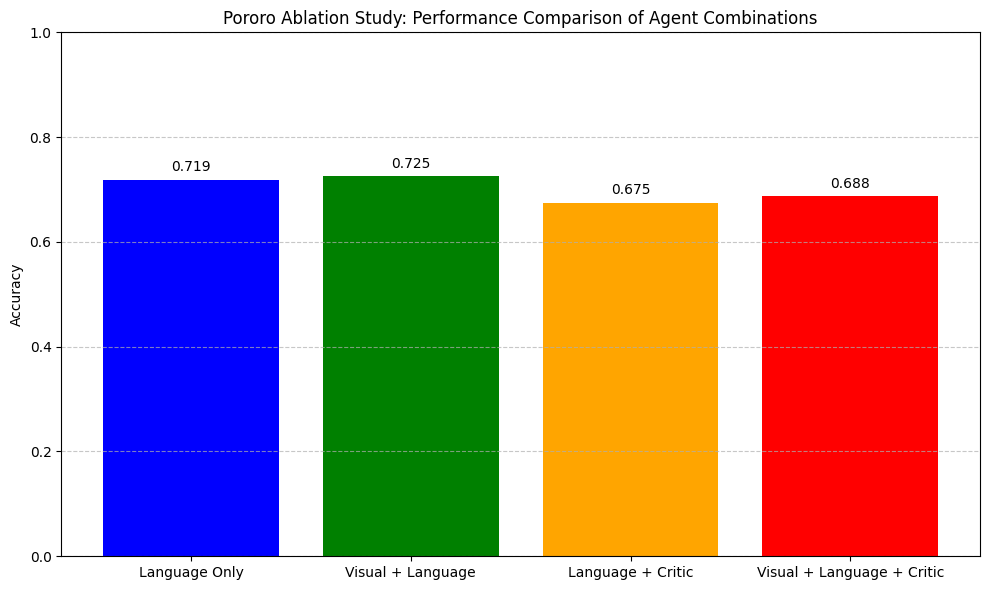

Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_comparison.csv

Final comparison data:
                Configuration  Accuracy
0               Language Only   0.71875
1           Visual + Language   0.72500
2           Language + Critic   0.67500
3  Visual + Language + Critic   0.68750


In [7]:
# Create visualization of ablation results
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + Critic": all_accuracies.get('language_critic', 0),
    "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
}

# Create a folder to save figures if not exist
os.makedirs("saved_figures", exist_ok=True)

# Generate timestamp for unique figure name
timestamp = time.strftime("%Y%m%d_%H%M%S")
config_name = f"pororo_ablation_comparison_{timestamp}"

plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Pororo Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure with a unique name
plt.savefig(f"saved_figures/{config_name}_comparison_plot.png", dpi=300)
print(f"Visualization saved to: saved_figures/{config_name}_comparison_plot.png")

plt.show()

comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
comparison_path = os.path.join(os.getcwd(), "results", "ablation", "pororo_ablation_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparison results saved to: {comparison_path}")
print(f"\nFinal comparison data:\n{comparison_df}")